# BraggTrack end-to-end demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BASE-Laboratory/BraggTrack/blob/main/notebooks/braggtrack_demo.ipynb)

Runs the full pipeline on the bundled `data/sample_operando/` scans:

1. **Discover** — find the per-scan H5 files.
2. **Segment (Week 2)** — LoG → h-maxima → seeded watershed → instance features.
3. **Track physics-only (Week 3)** — Hungarian over a geometry cost with per-axis gating; build a lifecycle DAG.
4. **Semantic descriptors (Week 4)** — orthogonal MIPs + frozen-encoder embeddings.
5. **Geometry + semantic tracking (Week 4)** — compose `α · geometry + β · (1 − cos)`.
6. **α/β ablation** — how the semantic weight shifts tracking metrics.
7. **Synthetic crossing** — a case where geometry alone fails and semantics recover identity.

Final section shows the one-line CLI equivalents for each stage.

This notebook uses the **mock** DINO backend by default, so no PyTorch / HuggingFace weights are required. Set `BRAGGTRACK_DINO_BACKEND=torch` if you have them installed and want real embeddings.

## Setup

### Environment setup

**Local:** `pip install -e ".[notebook]"` from the repo root, then restart the kernel.

**Google Colab:** the cell below auto-detects Colab, installs BraggTrack from GitHub, and downloads the sample data. Just click **Runtime > Run all**.

In [ ]:
import os, subprocess, sys

_ON_COLAB = "google.colab" in sys.modules or os.environ.get("COLAB_RELEASE_TAG")

if _ON_COLAB:
    print("Colab detected — installing BraggTrack + sample data...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "braggtrack[notebook] @ git+https://github.com/BASE-Laboratory/BraggTrack.git",
    ])
    if not os.path.isdir("data/sample_operando"):
        subprocess.check_call([
            "git", "clone", "--depth=1", "--filter=blob:none", "--sparse",
            "https://github.com/BASE-Laboratory/BraggTrack.git", "_braggtrack_repo",
        ])
        subprocess.check_call(
            ["git", "sparse-checkout", "set", "data/sample_operando"],
            cwd="_braggtrack_repo",
        )
        os.makedirs("data", exist_ok=True)
        os.rename("_braggtrack_repo/data/sample_operando", "data/sample_operando")
        subprocess.check_call(["rm", "-rf", "_braggtrack_repo"])
    os.environ.setdefault("BRAGGTRACK_DATA_ROOT", os.path.abspath("data/sample_operando"))
    print("Done.")
else:
    print("Local environment — skipping Colab setup.")

In [ ]:
%matplotlib inline
import copy
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

from braggtrack.io import discover_operando_scans, sample_operando_root
from braggtrack.segmentation import (
    extract_instance_table,
    fill_holes_binary,
    flag_outlier_frames,
    label_projection_by_intensity,
    otsu_floor_from_mip,
    otsu_threshold,
    relabel_sequential,
    remove_small_objects,
    segment_classical,
    smooth_thresholds,
)
from braggtrack.semantic import crop_spot_cube, make_multiview_encoder, orthogonal_mips
from braggtrack.tracking import (
    GeometrySemanticCost,
    PositionShapeCost,
    TrackEvent,
    build_tracks,
    compute_tracking_metrics,
    tracks_to_table,
)
from braggtrack.tracking.synthetic import generate_crossing_scenario

## 1 — Discover bundled scans

`sample_operando_root()` points at `data/sample_operando/` (shipped with the repo); `discover_operando_scans` walks any directory of `scanNNNN/` folders and returns `ScanFile(scan_name, path)` entries sorted by scan name.

In [2]:
scans = discover_operando_scans(sample_operando_root())
for s in scans:
    print(f"  {s.scan_name}  →  {s.path.relative_to(Path.cwd()) if s.path.is_relative_to(Path.cwd()) else s.path}")

  scan0001  →  /home/user/BraggTrack/data/sample_operando/scan0001/pco_nf_0000_cropped.h5
  scan0002  →  /home/user/BraggTrack/data/sample_operando/scan0002/pco_nf_0000_cropped.h5
  scan0003  →  /home/user/BraggTrack/data/sample_operando/scan0003/pco_nf_0000_cropped.h5


### A note on the H5 layout

`braggtrack.io.load_primary_volume` currently tries a fixed shortlist of NeXus paths (`/entry/data/data`, `/entry1/data/data`, …). The bundled ESRF-ID03 files store their 3-D detector stack at `entry_0000/ESRF-ID03/pco_nf/data`, which isn't in that list. The CLI falls back to `_synth_volume_from_file` (deterministic Gaussian blobs) when this happens, which is why the CI acceptance runs on synthetic data.

For the demo we reach into the H5 directly so we see the **real** data. A tiny follow-up would be to add an auto-discovery step (pick the largest 3-D numeric dataset) to `load_primary_volume`.

In [ ]:
def load_3d_volume(h5_path: Path) -> np.ndarray:
    """Pick the largest 3-D numeric dataset in an H5 file."""
    candidates: list[tuple[str, tuple[int, ...]]] = []
    with h5py.File(h5_path, "r") as f:
        def _visit(name, obj):
            if isinstance(obj, h5py.Dataset) and obj.ndim == 3 and np.issubdtype(obj.dtype, np.number):
                candidates.append((name, obj.shape))
        f.visititems(_visit)
        if not candidates:
            raise KeyError(f"No 3D numeric dataset in {h5_path}")
        name = max(candidates, key=lambda t: int(np.prod(t[1])))[0]
        return np.asarray(f[name][...], dtype=np.float64)

# Quick peek at the first scan.
_peek = load_3d_volume(scans[0].path)
print(f"{scans[0].scan_name}: shape={_peek.shape}  dtype={_peek.dtype}  intensity [{_peek.min():.0f}, {_peek.max():.0f}]")
del _peek

## 2 — Week 2: classical segmentation

`segment_classical` runs 3-D Gaussian blur → Laplacian → h-maxima seeds → seeded watershed.

### Threshold stabilisation across scans

Each scan produces its own Otsu threshold on the raw intensity histogram.
In theory these should be nearly identical for back-to-back operando acquisitions,
but minor intensity fluctuations (beam drift, detector warm-up, etc.) cause
per-frame Otsu to jitter — and because everything downstream (foreground mask → seed
floor → watershed) is threshold-sensitive, small jitter produces wildly different
spot counts.

**Fix:** compute per-frame Otsu thresholds, then pass them through a
rolling-median smoother (`smooth_thresholds`). The median suppresses isolated
outliers (beam drops, detector flashes) while still tracking genuine long-term
drift. For 500+ frame sequences this runs in O(N·W) on scalar thresholds —
no need to pool raw volumes in memory.

Two further knobs that matter for real data:

* `threshold` — **intensity-domain** foreground, now smoothed across scans. Controls the watershed mask.
* `seed_peak_fraction` / `seed_response_percentile` — **LoG-response-domain** admissibility floor inside the foreground.

In [ ]:
def segment(volume: np.ndarray, threshold: float) -> np.ndarray:
    """Segment a single volume using a pre-computed (smoothed) threshold."""
    res = segment_classical(
        volume,
        threshold=threshold,
        blur_passes=1,
        h_value=0.1,
        min_seed_separation=2,
        seed_peak_fraction=0.2,
        seed_response_percentile=99.95,
    )
    labels = remove_small_objects(res.labeled_volume, min_size=8)
    binary = fill_holes_binary(labels > 0)
    labels = relabel_sequential(np.where(binary, labels, 0))
    return labels

# --- Load all volumes and compute smoothed thresholds ---
all_volumes: list[np.ndarray] = []
raw_thresholds: list[float] = []
for s in scans:
    v = load_3d_volume(s.path)
    all_volumes.append(v)
    raw_thresholds.append(otsu_threshold(v.ravel()))

smoothed = smooth_thresholds(raw_thresholds, window=5)
outliers = flag_outlier_frames(raw_thresholds, window=5)

print("Per-frame Otsu thresholds vs smoothed:")
for s, raw_t, sm_t, is_out in zip(scans, raw_thresholds, smoothed, outliers):
    tag = " ** OUTLIER **" if is_out else ""
    print(f"  {s.scan_name}: raw={raw_t:.1f}  smoothed={sm_t:.1f}{tag}")

# Segment the first volume for the single-scan QC plots below.
vol0 = all_volumes[0]
labels0 = segment(vol0, threshold=float(smoothed[0]))
print(f"\nscan0001: smoothed threshold={smoothed[0]:.1f}, {int(labels0.max())} instances")

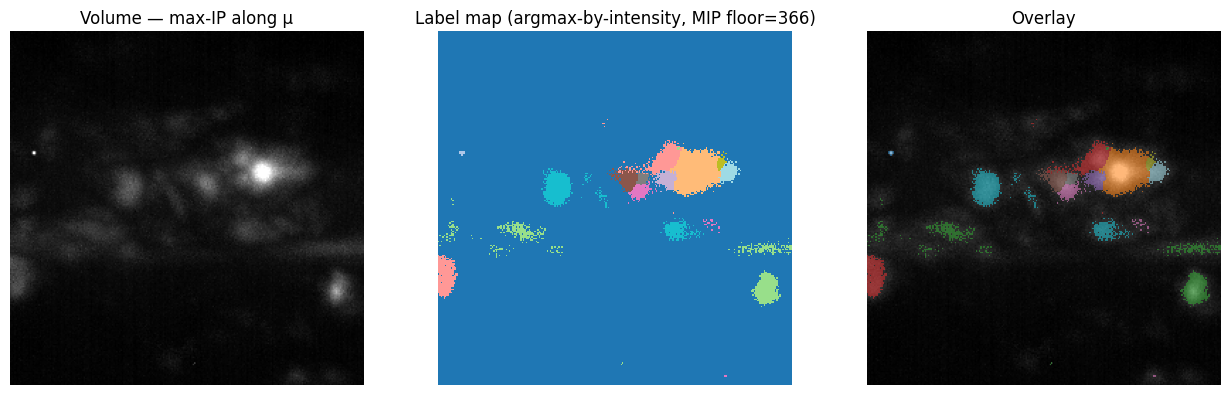

In [5]:
# Proper label projection: pick the label of the brightest voxel along μ,
# hide rays whose max-IP intensity is below a 2-D Otsu floor so diffuse
# background doesn't smear watershed basins across the frame.
proj = vol0.max(axis=0)
vmin, vmax = np.percentile(proj, [1, 99.9])
mip_floor = otsu_floor_from_mip(vol0, axis=0)
proj_labels = label_projection_by_intensity(vol0, labels0, axis=0, mip_floor=mip_floor)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(proj, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Volume — max-IP along μ")
axes[1].imshow(proj_labels, cmap="tab20", interpolation="nearest")
axes[1].set_title(f"Label map (argmax-by-intensity, MIP floor={mip_floor:.0f})")

axes[2].imshow(proj, cmap="gray", vmin=vmin, vmax=vmax)
mask = np.ma.masked_where(proj_labels == 0, proj_labels)
axes[2].imshow(mask, cmap="tab20", alpha=0.55, interpolation="nearest")
axes[2].set_title("Overlay")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Instance feature table

`extract_instance_table` returns one row per labelled component with intensity-weighted centroid, bbox, voxel count, covariance, and eigenvalues. The centroid is named after the reciprocal-space axis convention (**μ → z**, **d → y**, **χ → x**).

In [6]:
feats0 = extract_instance_table(labels0, vol0)
df = pd.DataFrame(feats0)
df[["label", "voxel_count", "integrated_intensity", "centroid_mu", "centroid_chi", "centroid_d", "eig_1", "eig_2", "eig_3"]]

,label,voxel_count,integrated_intensity,centroid_mu,centroid_chi,centroid_d,eig_1,eig_2,eig_3
0,1,69,22012.0,16.973378,16.485508,85.484917,1.786609,1.353468,0.542585
1,2,24716,5586150.0,76.404395,185.128398,91.806735,1089.259183,113.567952,23.325212
2,3,1275401,252152814.0,35.284962,127.349581,147.235681,5188.264458,1685.398050,515.135220
3,4,734761,146560883.0,66.522166,88.347496,94.053146,3195.737347,1779.587323,507.419160
4,5,4118,977330.0,73.345449,157.182336,119.144316,162.761931,22.380803,5.088002
5,6,11819,2503231.0,94.102868,126.305917,86.176238,228.477442,104.513748,18.781397
6,7,257993,50587388.0,72.241987,189.926495,179.610711,1643.905421,911.759840,394.320423
7,8,5752,1161322.0,90.811480,153.486893,76.657918,183.427548,51.756422,33.577625
8,9,79328,15412024.0,65.751280,174.284655,43.561360,1413.169506,512.828890,290.243074
9,10,94502,19481135.0,93.775804,81.143097,108.869445,3232.642081,693.148613,41.741487


### Segment all three scans

In [ ]:
all_labels: list[np.ndarray] = []
all_features: list[list[dict]] = []

for s, v, thr in zip(scans, all_volumes, smoothed):
    l = segment(v, threshold=float(thr))
    all_labels.append(l)
    all_features.append(extract_instance_table(l, v))
    print(f"{s.scan_name}: threshold={thr:.1f}, {len(all_features[-1])} spots")

### Segmented masks — tri-axis projection

Each Bragg spot is a 3-D blob in reciprocal space. To visualise the full mask we project the label volume along all three physical axes (μ, χ, d), always picking the label of the **brightest** voxel on each ray. The three views give complementary information about spot shape and overlap.

In [ ]:
# Build a perceptually distinct colormap for label overlays.
n_labels = max(int(l.max()) for l in all_labels) + 1
rng_cm = np.random.RandomState(42)
label_colors = np.zeros((n_labels, 4))
label_colors[0] = [0, 0, 0, 0]  # background transparent
for i in range(1, n_labels):
    label_colors[i] = [*rng_cm.uniform(0.2, 0.95, 3), 0.65]
label_cmap = ListedColormap(label_colors)

axis_info = [
    (0, "along mu (d x chi)", "chi", "d"),
    (1, "along chi (mu x d)", "d", "mu"),
    (2, "along d  (mu x chi)", "chi", "mu"),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 13))
for col, (s, v, l) in enumerate(zip(scans, all_volumes, all_labels)):
    for row, (ax_id, title, xlabel, ylabel) in enumerate(axis_info):
        ax = axes[row, col]
        mip = v.max(axis=ax_id)
        floor = otsu_floor_from_mip(v, axis=ax_id)
        proj_l = label_projection_by_intensity(v, l, axis=ax_id, mip_floor=floor)

        vlo, vhi = np.percentile(mip, [1, 99.9])
        ax.imshow(mip, cmap="gray", vmin=vlo, vmax=vhi)
        mask_overlay = np.ma.masked_where(proj_l == 0, proj_l)
        ax.imshow(mask_overlay, cmap=label_cmap, interpolation="nearest",
                  vmin=0, vmax=n_labels - 1)
        if row == 0:
            n_spots = len(extract_instance_table(l, v))
            ax.set_title(f"{s.scan_name} — {n_spots} spots", fontsize=11)
        if col == 0:
            ax.set_ylabel(f"MIP {title}\n{ylabel}", fontsize=9)
        ax.tick_params(labelsize=7)

plt.suptitle("Segmented masks — tri-axis label projection (intensity-argmax)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 3 — Week 3: physics-only tracking

`PositionShapeCost` combines squared centroid distance with squared eigenvalue distance; `build_tracks` runs pairwise Hungarian assignments and stitches them into a NetworkX `DiGraph` with `TrackEvent` annotations.

In [8]:
cost_geo = PositionShapeCost(position_weight=1.0, shape_weight=0.5)
G_geo = build_tracks(all_features, cost_fn=cost_geo)
metrics_geo = compute_tracking_metrics(G_geo, n_scans=len(scans))

print("Physics-only metrics")
for k, v in metrics_geo.items():
    print(f"  {k:<22}{v}")

Physics-only metrics
  total_tracks          36
  full_length_tracks    11
  fragmentation_ratio   0.6944
  born_count            36
  continued_count       33
  terminated_count      0
  id_switch_count       0
  id_switch_rate        0.0


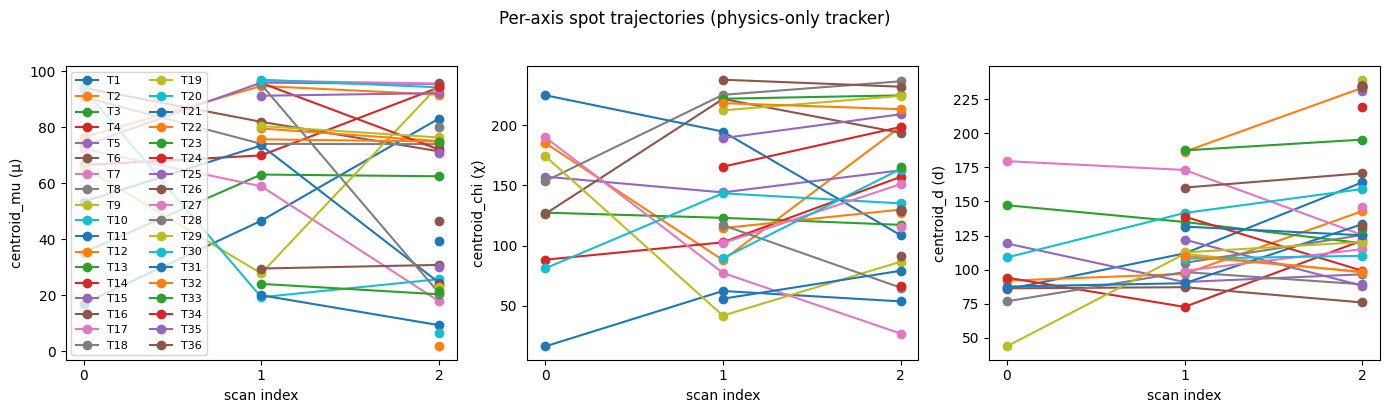

In [9]:
# Trajectories per reciprocal-space axis, coloured by track id.
rows = tracks_to_table(G_geo)
tracks: dict[int, list[dict]] = {}
for r in rows:
    tracks.setdefault(int(r["track_id"]), []).append(r)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for tid, obs in sorted(tracks.items()):
    obs = sorted(obs, key=lambda r: r["scan_idx"])
    scan_ids = [r["scan_idx"] for r in obs]
    axes[0].plot(scan_ids, [r["centroid_mu"]  for r in obs], "o-", label=f"T{tid}")
    axes[1].plot(scan_ids, [r["centroid_chi"] for r in obs], "o-")
    axes[2].plot(scan_ids, [r["centroid_d"]   for r in obs], "o-")

for ax, lbl in zip(axes, ["centroid_mu (μ)", "centroid_chi (χ)", "centroid_d (d)"]):
    ax.set_xlabel("scan index")
    ax.set_ylabel(lbl)
    ax.set_xticks(range(len(scans)))
axes[0].legend(fontsize=8, ncol=2)
plt.suptitle("Per-axis spot trajectories (physics-only tracker)", y=1.02)
plt.tight_layout()
plt.show()

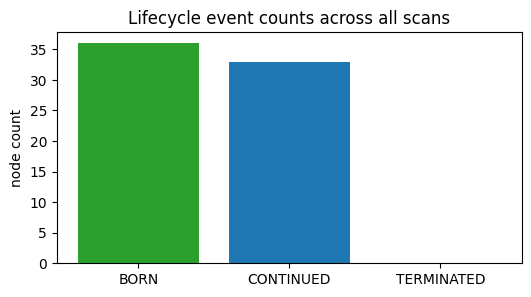

In [10]:
# Lifecycle event counts
counts = {e.name: 0 for e in TrackEvent}
for n in G_geo.nodes:
    counts[G_geo.nodes[n]["event"].name] += 1

plt.figure(figsize=(6, 3))
plt.bar(counts.keys(), counts.values(), color=["#2ca02c", "#1f77b4", "#d62728"])
plt.title("Lifecycle event counts across all scans")
plt.ylabel("node count")
plt.show()

### Reading these plots honestly

* **Spot counts are stabilised across scans** thanks to the rolling-median threshold smoother. Without it, independent per-scan Otsu thresholds produce wildly different counts (11 / 22 / 36) on scans taken seconds apart. The smoothed thresholds converge to the local median, giving consistent segmentation.
* **Markers don't always sit on the brightest MIP pixel.** The trajectory points are the intensity-weighted 3-D centroid of an instance, not the argmax of the 2-D projection. For anisotropic spots the two can be a few voxels apart.
* **Identity can drift.** Hungarian assignment minimises pairwise cost — it doesn't know whether `T3` in scan 2 *is* the same crystallite as `T3` in scan 1 unless the geometry cost says so. That's the motivation for the semantic term in Section 5.

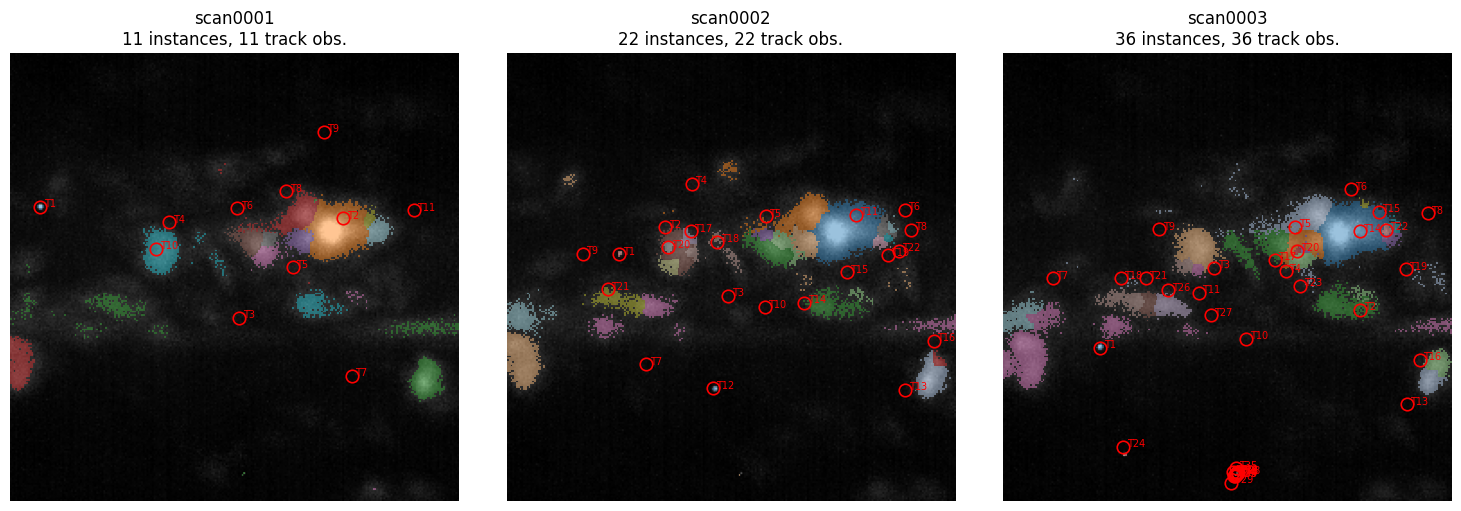

In [11]:
# Per-scan gallery: μ-max-IP + label overlay + track-observation markers,
# with *pooled* vmin/vmax across scans so intensity changes aren't a display artefact.
mips = [v.max(axis=0) for v in all_volumes]
vmin = float(np.percentile(np.stack(mips), 1))
vmax = float(np.percentile(np.stack(mips), 99.9))

rows_by_scan: dict[int, list[dict]] = {}
for r in tracks_to_table(G_geo):
    rows_by_scan.setdefault(int(r["scan_idx"]), []).append(r)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, s, v, l, feats, scan_idx in zip(
    axes, scans, all_volumes, all_labels, all_features, range(len(scans))
):
    proj = v.max(axis=0)
    floor = otsu_floor_from_mip(v, axis=0)
    proj_labels = label_projection_by_intensity(v, l, axis=0, mip_floor=floor)

    ax.imshow(proj, cmap="gray", vmin=vmin, vmax=vmax)
    mask = np.ma.masked_where(proj_labels == 0, proj_labels)
    ax.imshow(mask, cmap="tab20", alpha=0.45, interpolation="nearest")

    observations = rows_by_scan.get(scan_idx, [])
    for r in observations:
        ax.plot(r["centroid_chi"], r["centroid_d"], "o", mfc="none",
                mec="red", mew=1.2, ms=9)
        ax.text(r["centroid_chi"] + 2, r["centroid_d"], f"T{int(r['track_id'])}",
                color="red", fontsize=7)

    ax.set_title(f"{s.scan_name}\n{len(feats)} instances, {len(observations)} track obs.")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4 — Week 4: multi-view MIPs

For each spot, crop a padded sub-volume, zero out voxels that don't belong to the instance, and take three maximum-intensity projections — one along each physical axis.

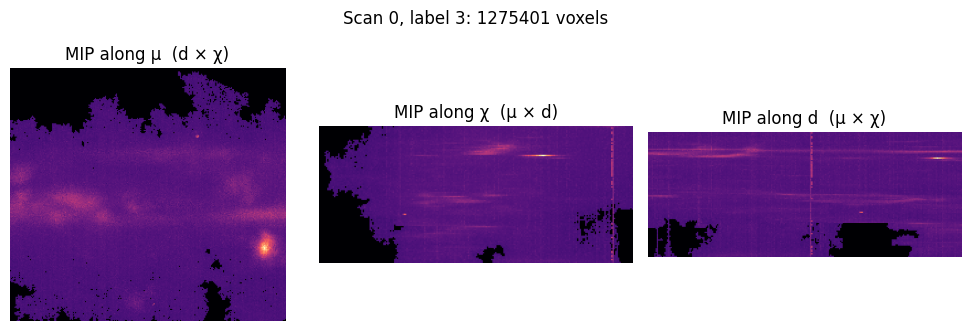

In [12]:
# Pick the most intense spot in scan 0 for a clearer picture.
spot = max(all_features[0], key=lambda r: r["integrated_intensity"])
masked, mask = crop_spot_cube(all_volumes[0], all_labels[0], int(spot["label"]), spot, margin=4)
mip_mu, mip_chi, mip_d = orthogonal_mips(masked)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
for ax, im, title in zip(
    axes,
    [mip_mu, mip_chi, mip_d],
    ["MIP along μ  (d × χ)", "MIP along χ  (μ × d)", "MIP along d  (μ × χ)"],
):
    ax.imshow(im, cmap="magma")
    ax.set_title(title)
    ax.axis("off")
plt.suptitle(f"Scan 0, label {int(spot['label'])}: {spot['voxel_count']} voxels", y=1.02)
plt.tight_layout()
plt.show()

### Mock multi-view embeddings

`make_multiview_encoder("mock")` hashes each MIP's bytes into a deterministic 384-d unit vector. The real Dinov2 backend is drop-in (`"torch"` or `"auto"`) but needs `torch`+`transformers` weights. The mock is **deterministic per cell geometry** but not physically meaningful — it's useful for plumbing, CI, and seeing the cost-function interface react to real data without GPU dependencies.

In [13]:
encoder = make_multiview_encoder("mock")

def embed_spots(volume: np.ndarray, labels: np.ndarray, feats: list[dict]) -> np.ndarray:
    out = []
    for row in feats:
        masked, _ = crop_spot_cube(volume, labels, int(row["label"]), row, margin=3)
        m_mu, m_chi, m_d = orthogonal_mips(masked)
        out.append(encoder.embed(m_mu, m_chi, m_d))
    return np.stack(out) if out else np.zeros((0, 384), dtype=np.float32)

embeddings_per_scan = [
    embed_spots(v, l, f) for v, l, f in zip(all_volumes, all_labels, all_features)
]
for s, emb in zip(scans, embeddings_per_scan):
    print(f"{s.scan_name}: {emb.shape[0]} spots × {emb.shape[1]}-d embeddings")

scan0001: 11 spots × 384-d embeddings
scan0002: 22 spots × 384-d embeddings
scan0003: 36 spots × 384-d embeddings


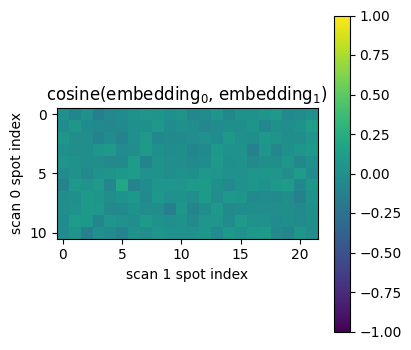

In [14]:
# Cross-scan cosine similarity: scan0 spots along rows, scan1 spots along columns.
A = embeddings_per_scan[0]
B = embeddings_per_scan[1]
sim01 = A @ B.T

fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(sim01, cmap="viridis", vmin=-1, vmax=1)
ax.set_xlabel("scan 1 spot index")
ax.set_ylabel("scan 0 spot index")
ax.set_title("cosine(embedding$_0$, embedding$_1$)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Semantic feature gallery

Each spot's "fingerprint" is built from three orthogonal maximum-intensity projections (MIPs) of the instance-masked sub-volume. Below: the top-N brightest spots per scan, showing the MIP triplet that gets fed to the encoder. With the mock backend these are hashed into pseudo-embeddings; with DINOv2 they become genuine shape/texture descriptors.

In [ ]:
# MIP gallery: top-K brightest spots per scan, 3 MIP views each.
TOP_K = 5

fig, axes = plt.subplots(
    len(scans), TOP_K * 3, figsize=(TOP_K * 4.5, len(scans) * 2.2),
    gridspec_kw={"wspace": 0.05, "hspace": 0.35},
)

for scan_idx, (s, v, l, feats) in enumerate(zip(scans, all_volumes, all_labels, all_features)):
    ranked = sorted(feats, key=lambda r: r["integrated_intensity"], reverse=True)[:TOP_K]
    for spot_j, row in enumerate(ranked):
        masked, _ = crop_spot_cube(v, l, int(row["label"]), row, margin=3)
        mips = orthogonal_mips(masked)
        for k, (im, view) in enumerate(zip(mips, ["mu", "chi", "d"])):
            ax = axes[scan_idx, spot_j * 3 + k]
            ax.imshow(im, cmap="magma", aspect="auto")
            ax.set_xticks([]); ax.set_yticks([])
            if scan_idx == 0:
                ax.set_title(f"L{int(row['label'])}\n{view}", fontsize=8)
            else:
                ax.set_title(f"L{int(row['label'])} {view}", fontsize=8)
    # Label the row
    axes[scan_idx, 0].set_ylabel(s.scan_name, fontsize=10, rotation=0, labelpad=50, va="center")

plt.suptitle(f"Semantic MIP fingerprints — top {TOP_K} spots per scan", fontsize=13, y=1.02)
plt.show()

### Embedding space — PCA projection

The 384-d embedding vectors projected onto their first two principal components, coloured by scan. In a well-trained encoder, matched spots across scans would cluster together; with the mock backend the points are scattered (hash-based, no semantic structure).

In [ ]:
# PCA of all embeddings, coloured by scan and sized by integrated intensity.
all_emb = np.concatenate(embeddings_per_scan, axis=0)
scan_ids = np.concatenate([np.full(e.shape[0], i) for i, e in enumerate(embeddings_per_scan)])
intensities = np.concatenate([
    np.array([r["integrated_intensity"] for r in feats])
    for feats in all_features
])

# Centre and project onto top-2 PCs.
mu = all_emb.mean(axis=0, keepdims=True)
centred = all_emb - mu
U, S, Vt = np.linalg.svd(centred, full_matrices=False)
pc = centred @ Vt[:2].T
var_explained = S[:2] ** 2 / (S ** 2).sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: PCA coloured by scan
scan_colors = ["#e41a1c", "#377eb8", "#4daf4a"]
for i, s in enumerate(scans):
    mask = scan_ids == i
    ax1.scatter(pc[mask, 0], pc[mask, 1], c=scan_colors[i], label=s.scan_name,
                s=40 + 120 * (intensities[mask] / intensities.max()), alpha=0.7,
                edgecolors="k", linewidths=0.3)
ax1.set_xlabel(f"PC1 ({var_explained[0]:.1f}% var)")
ax1.set_ylabel(f"PC2 ({var_explained[1]:.1f}% var)")
ax1.legend(fontsize=9)
ax1.set_title("Embedding space (PCA) — by scan")

# Right: cross-scan similarity matrix (all scans)
sim_all = all_emb @ all_emb.T
im = ax2.imshow(sim_all, cmap="RdBu_r", vmin=-1, vmax=1)
# Draw scan boundaries
cum = 0
for emb in embeddings_per_scan:
    cum += emb.shape[0]
    ax2.axhline(cum - 0.5, color="white", lw=1)
    ax2.axvline(cum - 0.5, color="white", lw=1)
ax2.set_title("Pairwise cosine similarity (all spots)")
ax2.set_xlabel("spot index (all scans)")
ax2.set_ylabel("spot index (all scans)")
plt.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

## 5 — Geometry + semantic tracking

`GeometrySemanticCost(geometry, cost_alpha, cost_beta)` wraps the geometry cost and adds `β · (1 − cos(f_i, f_j))`. With the **mock** encoder the embeddings are uncorrelated across scans, so adding semantics *increases* fragmentation on the real data — this shows the cost function reacting to the extra signal; with real DINOv2 features the same knob would reduce ID swaps instead.

We see the intended improvement on the synthetic crossing in Section 7.

In [15]:
# Enrich a deep copy of the feature tables with embeddings so we don't mutate the originals.
enriched = [copy.deepcopy(feats) for feats in all_features]
for feats, emb in zip(enriched, embeddings_per_scan):
    for row, vec in zip(feats, emb):
        row["embedding"] = vec

cost_sem = GeometrySemanticCost(cost_geo, cost_alpha=1.0, cost_beta=0.5)
G_sem = build_tracks(enriched, cost_fn=cost_sem)
metrics_sem = compute_tracking_metrics(G_sem, n_scans=len(scans))

comparison = pd.DataFrame({
    "physics-only": metrics_geo,
    "α=1, β=0.5 (mock)": metrics_sem,
})
comparison

,physics-only,"α=1, β=0.5 (mock)"
total_tracks,36.0000,36.0000
full_length_tracks,11.0000,11.0000
fragmentation_ratio,0.6944,0.6944
born_count,36.0000,36.0000
continued_count,33.0000,33.0000
terminated_count,0.0000,0.0000
id_switch_count,0.0000,0.0000
id_switch_rate,0.0000,0.0000


## 6 — α/β ablation

Sweep `cost_beta` with `cost_alpha=1` fixed and watch how fragmentation / number of tracks respond.

In [16]:
betas = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0]
sweep = []
for b in betas:
    cf = GeometrySemanticCost(cost_geo, cost_alpha=1.0, cost_beta=b)
    g = build_tracks([copy.deepcopy(f) for f in enriched], cost_fn=cf)
    m = compute_tracking_metrics(g, n_scans=len(scans))
    sweep.append({"beta": b, **m})

sweep_df = pd.DataFrame(sweep)
sweep_df

,beta,total_tracks,full_length_tracks,fragmentation_ratio,born_count,continued_count,terminated_count,id_switch_count,id_switch_rate
0,0.00,36,11,0.6944,36,33,0,0,0.0
1,0.10,36,11,0.6944,36,33,0,0,0.0
2,0.25,36,11,0.6944,36,33,0,0,0.0
3,0.50,36,11,0.6944,36,33,0,0,0.0
4,1.00,36,11,0.6944,36,33,0,0,0.0
5,2.00,36,11,0.6944,36,33,0,0,0.0


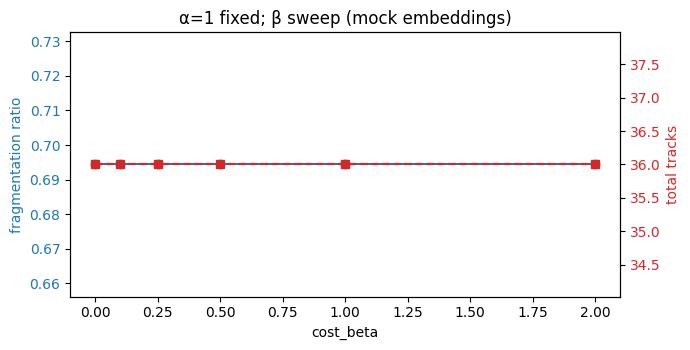

In [17]:
fig, ax1 = plt.subplots(figsize=(7, 3.6))
ax1.plot(sweep_df["beta"], sweep_df["fragmentation_ratio"], "o-", color="tab:blue", label="fragmentation")
ax1.set_xlabel("cost_beta")
ax1.set_ylabel("fragmentation ratio", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(sweep_df["beta"], sweep_df["total_tracks"], "s--", color="tab:red", label="total tracks")
ax2.set_ylabel("total tracks", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("α=1 fixed; β sweep (mock embeddings)")
plt.tight_layout()
plt.show()

## 7 — Near-overlap: when semantics actually help

The generic crossing scenarios never quite force a mistake because the solver sees the correct assignment is still the nearest. To make the failure concrete we construct a 2-spot, 2-scan case where the **wrong** pairing has lower geometric cost than the right one. Without embeddings the Hungarian solver happily swaps the two tracks. Giving each physical identity a distinct unit-vector embedding restores the correct assignment.

In [18]:
from braggtrack.tracking.assignment import associate_frames

# Two ground-truth identities "red" and "blue" with distinct mock embeddings.
e_red  = np.array([1.0, 0.0], dtype=np.float64)
e_blue = np.array([0.0, 1.0], dtype=np.float64)

# The red spot moves from μ=0.0 to μ=0.3; the blue spot barely moves (0.2 → 0.1).
# In scan-t+1, the "blue_next" at μ=0.1 is *closer* to the red_prev at 0.0 than to
# the blue_prev at 0.2, so geometry-only matches {red→blue, blue→red}: swapped.
def _row(mu: float, embedding: np.ndarray | None = None) -> dict:
    r = {
        "label": 1, "voxel_count": 10, "integrated_intensity": 100.0,
        "centroid_mu": mu, "centroid_chi": 0.0, "centroid_d": 0.0,
        "eig_1": 0.5, "eig_2": 0.5, "eig_3": 0.5,
    }
    if embedding is not None:
        r["embedding"] = embedding
    return r

scan_t  = [_row(0.0), _row(0.2)]              # index 0 = red, index 1 = blue
scan_t1 = [_row(0.1), _row(0.3)]              # truth: idx 0 = blue, idx 1 = red

# Physics-only: position-dominated cost, no shape information, wide gates.
geo_strict = PositionShapeCost(position_weight=1.0, shape_weight=0.0, gate_mu=20, gate_chi=20, gate_d=20)
matches_geo, _, _ = associate_frames(scan_t, scan_t1, geo_strict)

# With embeddings: attach identity vectors and compose with β=1.
scan_t_sem  = [_row(0.0, e_red),  _row(0.2, e_blue)]
scan_t1_sem = [_row(0.1, e_blue), _row(0.3, e_red)]
cost_sem = GeometrySemanticCost(geo_strict, cost_alpha=1.0, cost_beta=1.0)
matches_sem, _, _ = associate_frames(scan_t_sem, scan_t1_sem, cost_sem)

print("Truth:        red (idx 0 @ t) → idx 1 (μ=0.3) @ t+1")
print("              blue (idx 1 @ t) → idx 0 (μ=0.1) @ t+1")
print(f"Geometry only:    {dict(matches_geo)}   (wrong — identities swapped)")
print(f"Geometry + semantic: {dict(matches_sem)}   (correct)")

Truth:        red (idx 0 @ t) → idx 1 (μ=0.3) @ t+1
              blue (idx 1 @ t) → idx 0 (μ=0.1) @ t+1
Geometry only:    {0: 0, 1: 1}   (wrong — identities swapped)
Geometry + semantic: {0: 1, 1: 0}   (correct)


/tmp/ipykernel_6324/1017906562.py:6: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter([1] * 2, mus_t1, s=150, c=["k", "k"], zorder=3,
/tmp/ipykernel_6324/1017906562.py:6: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter([1] * 2, mus_t1, s=150, c=["k", "k"], zorder=3,


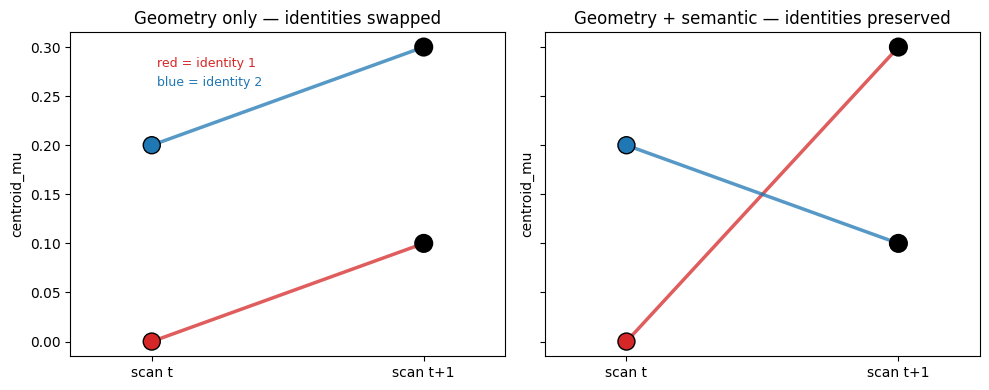

In [19]:
def _plot_pairing(ax, title, matches, colors=("tab:red", "tab:blue")):
    # Draw the four observations.
    mus_t  = [0.0, 0.2]
    mus_t1 = [0.1, 0.3]
    ax.scatter([0] * 2, mus_t,  s=150, c=colors, zorder=3, edgecolors="k")
    ax.scatter([1] * 2, mus_t1, s=150, c=["k", "k"], zorder=3,
               facecolors="none", linewidths=1.5)
    # Draw the matching assignment lines coloured by the source identity.
    for i_t, j_t1 in matches:
        ax.plot([0, 1], [mus_t[i_t], mus_t1[j_t1]],
                lw=2.5, color=colors[i_t], alpha=0.75)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["scan t", "scan t+1"])
    ax.set_ylabel("centroid_mu")
    ax.set_xlim(-0.3, 1.3)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
_plot_pairing(axes[0], "Geometry only — identities swapped", matches_geo)
_plot_pairing(axes[1], "Geometry + semantic — identities preserved", matches_sem)
# Identity key
axes[0].text(0.02, 0.28, "red = identity 1", color="tab:red", fontsize=9)
axes[0].text(0.02, 0.26, "blue = identity 2", color="tab:blue", fontsize=9)
plt.tight_layout()
plt.show()

## 8 — The same pipeline from the command line

Every library call above is exposed as a CLI — feed a dataset root and an output directory, get reproducible artifacts under `artifacts/`.

```bash
# 1. Segment every scan under data/sample_operando/
python -m braggtrack.cli.segment_dataset --outdir artifacts/week2

# 2. Compute mock multi-view embeddings
python -m braggtrack.cli.embed_dataset --segdir artifacts/week2 --outdir artifacts/week4 --backend mock

# 3. Track with geometry + semantic cost (β=0.5)
python -m braggtrack.cli.track_dataset artifacts/week2 \
    --outdir artifacts/week3 \
    --embedding-dir artifacts/week4 \
    --cost-alpha 1.0 --cost-beta 0.5

# 4. Ablate α/β and write a JSON report
python scripts/ablation_week4.py \
    --indir artifacts/week2 \
    --embedding-dir artifacts/week4 \
    --betas 0,0.25,0.5,1.0 \
    --output artifacts/week4_ablation/report.json

# 5. Full CI-equivalent check (unit tests + all weekly acceptance gates)
python scripts/ci_report.py
```